# Task 7: Orthogonal Projections for Debiasing

**Goal**: Use geometric methods to remove gender bias from word vectors.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd() / "datasets"

# Load word vectors
with open(DATA_DIR / "tiny_glove.json", "r", encoding="utf-8") as f:
    wv = json.load(f)

print(f"Loaded {len(wv)} vectors.")

Loaded 4993 vectors.


### Step 1: Defining the Gender Axis
We define a "gender direction" $g$ in the vector space by taking the difference between the vectors for "woman" and "man". 
$$g = \vec{v}_{woman} - \vec{v}_{man}$$
We then normalize this vector so it has a length of 1.

In [2]:
def get_vec(word):
    return np.array(wv[word], dtype=float)

# Define the gender axis
gender_axis = get_vec("woman") - get_vec("man")
# Normalize the axis
gender_axis /= np.linalg.norm(gender_axis)

print("Gender axis defined and normalized.")

Gender axis defined and normalized.


### Step 2: Measuring Bias
The bias of a word (e.g., "doctor") relative to the gender axis is the scalar projection of that word's vector onto the gender axis:
$$\text{bias} = \vec{v}_{word} \cdot g$$
A positive value indicates a "female" lean, while a negative value indicates a "male" lean in the original training data.

In [3]:
professions = ["doctor", "nurse", "engineer", "teacher", "scientist", "secretary", "captain", "assistant"]
bias_scores = {}

for p in professions:
    if p in wv:
        v = get_vec(p)
        # Scalar projection (dot product since gender_axis is normalized)
        bias = np.dot(v, gender_axis)
        bias_scores[p] = bias
        print(f"Original bias in '{p}': {bias:.4f}")

Original bias in 'doctor': 0.5834
Original bias in 'nurse': 1.8750
Original bias in 'engineer': -0.4001
Original bias in 'teacher': 0.9166
Original bias in 'scientist': -0.2693
Original bias in 'secretary': -0.8829
Original bias in 'captain': -2.2928
Original bias in 'assistant': -0.6993


### Step 3: Orthogonal Projection for Debiasing
To remove the bias, we subtract the component of the vector that lies along the gender axis. This is the **Orthogonal Projection**:
$$\vec{v}_{debiased} = \vec{v}_{word} - (\vec{v}_{word} \cdot g) \cdot g$$
The resulting vector $\vec{v}_{debiased}$ is now orthogonal (perpendicular) to the gender axis.

Debiasing Results:
'doctor' -> New bias: -7.8546e-17
'nurse' -> New bias: 9.3160e-17
'engineer' -> New bias: -8.6585e-17
'teacher' -> New bias: -1.1399e-16
'scientist' -> New bias: 1.0842e-16
'secretary' -> New bias: 7.9040e-17
'captain' -> New bias: -2.8153e-16
'assistant' -> New bias: 1.2117e-16


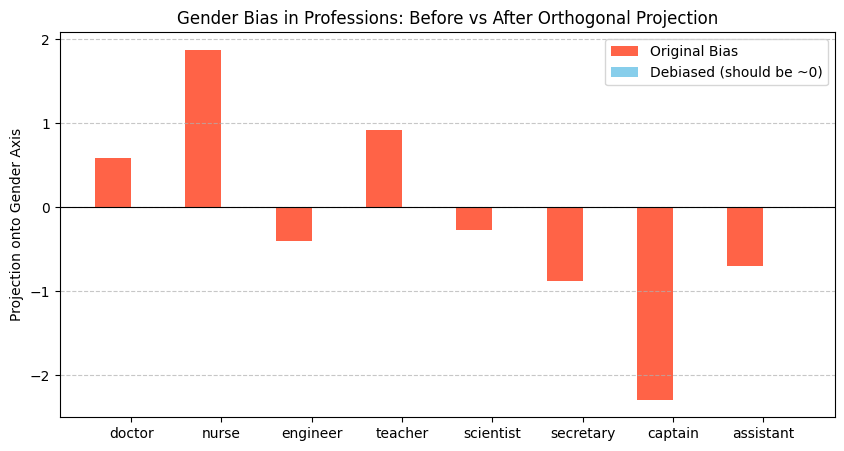

In [4]:
# Debiasing and plotting results
debiased_biases = []
original_biases = [bias_scores[p] for p in professions]

print("Debiasing Results:")
for p in professions:
    v = get_vec(p)
    # Remove the projection onto the gender axis
    v_debiased = v - np.dot(v, gender_axis) * gender_axis
    
    new_bias = np.dot(v_debiased, gender_axis)
    debiased_biases.append(new_bias)
    print(f"'{p}' -> New bias: {new_bias:.4e}")

# Visualization
plt.figure(figsize=(10, 5))
x = np.arange(len(professions))
plt.bar(x - 0.2, original_biases, 0.4, label='Original Bias', color='tomato')
plt.bar(x + 0.2, debiased_biases, 0.4, label='Debiased (should be ~0)', color='skyblue')

plt.xticks(x, professions)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Gender Bias in Professions: Before vs After Orthogonal Projection")
plt.ylabel("Projection onto Gender Axis")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()